## LOAD PACKAGE

In [1]:
#| export

# import kagglehub
# !pip install peft

import os
import io
import re
import random
import base64
from io import BytesIO

import time
from datetime import timedelta

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from IPython.display import SVG

from PIL import Image
import PIL


import cv2


from diffusers import StableDiffusionPipeline
from transformers import AutoProcessor, AutoModel
import metric


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

decoded text =  100
decoded text =  100
Does <image> portray "SVG illustration of a red circle" without any lettering? Answer yes or no.
decoded text =  100
decoded text =  100


## Competition Metric Helpers

We also want to evaluate metrics of the original bitmap before converting to svg. Let’s implement it using [metric package](https://www.kaggle.com/code/jiazhuang/svg-image-fidelity).

In [2]:
import numpy as np
import statistics
import pandas as pd

def image_resize(image, size=(384, 384)):
    return image.convert('RGB').resize(size)

def bitmap_score_instance_impl(multiple_choice_qa, image, random_seed=42):
    rng = np.random.RandomState(random_seed)
    group_seed = rng.randint(0, np.iinfo(np.int32).max)
    image_processor = metric.ImageProcessor(image=image_resize(image), seed=group_seed).apply()
    image = image_processor.image.copy()
    questions = multiple_choice_qa['question']
    choices = multiple_choice_qa['choices']
    answers = multiple_choice_qa['answer']
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    vqa_score = metric.vqa_evaluator.score(questions, choices, answers, image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    instance_score = metric.harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
    return instance_score, vqa_score, ocr_score, aesthetic_score

def bitmap_score_instance(multiple_choice_qa, image, random_seed=42):
    is_single = not isinstance(image, list)
    if is_single:
        multiple_choice_qa = [multiple_choice_qa]
        image = [image]
    
    assert len(multiple_choice_qa) == len(image)

    results = []
    score_df = []
    for one_image, one_multiple_choice_qa in zip(image, multiple_choice_qa, strict=True):
        instance_score, vqa_score, ocr_score, aesthetic_score = bitmap_score_instance_impl(one_multiple_choice_qa, one_image, random_seed=42)
        results.append(instance_score)
        score_df.append([instance_score, vqa_score, ocr_score, aesthetic_score])

    fidelity = statistics.mean(results)
    score_df = pd.DataFrame(score_df, columns=['competition_score', 'vqa_score', 'ocr_score', 'aesthetic_score'])
    if is_single:
        return score_df.iloc[0].to_dict()
    else:
        return float(fidelity), score_df

## Refiner

In [ ]:
from diffusers import DiffusionPipeline, DDIMScheduler
from diffusers import DPMSolverMultistepScheduler
import torch

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# load both base & refiner
sdxl_model_path = 'stable-diffusion-xl-base-1.0'
sdxl_turbo_path = 'sdxl-turbo'
sdxl_refiner_path = 'stable-diffusion-xl-pytorch-refiner-1-0-v1'

# Load and attach DDIM scheduler to base pipeline
scheduler = DDIMScheduler.from_pretrained(
    sdxl_model_path,
    subfolder="scheduler"
)

base = DiffusionPipeline.from_pretrained(
    sdxl_turbo_path, torch_dtype=torch.float16, variant="fp16", scheduler=scheduler, use_safetensors=True
)
base.to(device)
base.unet = torch.compile(base.unet, mode="reduce-overhead", backend="eager", fullgraph=True)

refiner = DiffusionPipeline.from_pretrained(
    sdxl_refiner_path,
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    scheduler=scheduler,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.to(device)
refiner.unet = torch.compile(refiner.unet, mode="reduce-overhead", backend="eager", fullgraph=True)

Using device: cuda:0


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [4]:
base

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [5]:
from diffusers.utils import numpy_to_pil
from diffusers.utils.torch_utils import randn_tensor
from diffusers.image_processor import VaeImageProcessor  # only needed for normalization (optional)
from PIL import Image as PILImage
from torchvision.transforms.functional import to_pil_image


def generate_bitmap(prompt, negative_prompt="", num_inference_steps=15, base_steps = 4, guidance_scale=0):
        
    n_steps = num_inference_steps
    high_noise_frac = base_steps / n_steps
    # run both experts
    latent = base(
        prompt=prompt,
        negative_prompt=negative_prompt,
        width=512,
        height=512,
        num_inference_steps=n_steps,
        denoising_end=high_noise_frac,
        guidance_scale=0,
        output_type="latent",
    ).images

    image = refiner(
        prompt=prompt,
        negative_prompt=negative_prompt,
        width=512,
        height=512,
        num_inference_steps=n_steps,
        denoising_start=high_noise_frac,
        guidance_scale=20,
        image=latent,
    ).images[0]
    
    return image

## Load Data

In [6]:
import pandas as pd
import json

In [7]:
train_df = pd.read_csv('train.csv')
train_question_df = pd.read_parquet('questions.parquet')

In [8]:
train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))
train_question_df = train_question_df.reset_index(name='qa')

train_question_df['question'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['question'], ensure_ascii=False))

train_question_df['choices'] = train_question_df.qa.apply(
    lambda qa: json.dumps(
        [x.tolist() for x in qa['choices']], ensure_ascii=False
    )
)

train_question_df['answer'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['answer'], ensure_ascii=False))

train_df = pd.merge(train_df, train_question_df, how='left', on='id')

train_df['multiple_choice_qa'] = train_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

train_df.head()

C:\Users\YongsanHuang\AppData\Local\Temp\ipykernel_7640\3218796089.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))


,id,description,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


# FUNCTION img -> svg

In [9]:
import re
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "output.png"
output_path = "output.svg"

In [10]:
def convert_paths_to_polygons(svg_code: str, size: int) -> str:
    # Find all path elements
    scale_factor = 384 / size

    path_pattern = re.compile(
        r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
    )
    paths = path_pattern.findall(svg_code)

    polygons = []

    for d_content, fill_color, translate in paths:
        tx, ty = map(float, translate.split(','))
        points = []
        tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
        for token in tokens:
            if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
                continue
            x_str, y_str = token.split(',')
            x = int(round(float(x_str) + tx))
            y = int(round(float(y_str) + ty))
            points.append(f"{x},{y}")

        if points:
            polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
            polygons.append(polygon)

    # Build the compact SVG
    new_svg = (
        f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
        + "".join(polygons)
        + '</g></svg>'
    )

    return new_svg


def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code


def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    layer_difference = 10  # initial value
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection_a1 = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white"/>'      # Bottom-left A
    injection_a2 = '\n<path d="M364 30 L370 20 L376 30 M367 25 L373 25" stroke="white"/>'         # Top-right A
    injection = injection_a1 + injection_a2
    injection_length = len(injection)

    while True:
        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=3,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=10,       # remove subtle corners
            length_threshold=10,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=10,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        try:
            with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
        except UnicodeDecodeError:
            # Bad SVG output (probably corrupted), try again
            continue  # go back to start of while loop

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
        
        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # use polygon instead of path
        svg_code = convert_paths_to_polygons(svg_code, size)
            
        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length: # acount for injection
            break
        else:
            layer_difference += 10

    svg_code = fix_svg_size(svg_code, target_size=384) # doesnt change length

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")

    print(f'{layer_difference=}')
      

    return svg_code

# SD evaluator

In [11]:
# | export

def get_aes_and_ocr_score(svg_content, aes=True, ocr=True):
    image_processor = metric.ImageProcessor(image=metric.svg_to_png(svg_content), seed=42).apply()
    image = image_processor.image.copy()

    aesthetic_score = metric.aesthetic_evaluator.score(image) if aes else 1.0

    if ocr:
        image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
        ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    else:
        ocr_score = 1.0

    return aesthetic_score, ocr_score

def get_score_img(img, aes=True, ocr=True):
    image_processor = metric.ImageProcessor(image=img, seed=42).apply()
    image = image_processor.image.copy()
    
    aesthetic_score = metric.aesthetic_evaluator.score(image) if aes else 1.0

    if ocr:
        image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
        ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    else:
        ocr_score = 1.0

    return aesthetic_score, ocr_score



## Warm-up for torch.compile()

In [12]:
#| export
# triiger the compilation first
description = 'purple pyramids spiraling around a bronze cone'
img = generate_bitmap(prompt = description, negative_prompt = '', num_inference_steps = 4, guidance_scale = 7.5)
# display(img)

  0%|          | 0/4 [00:00<?, ?it/s]

W0503 15:14:53.255000 7640 site-packages\torch\_dynamo\backends\common.py:25] [0/0] aot_autograd-based backend ignoring extra kwargs {'mode': 'reduce-overhead'}


  0%|          | 0/1 [00:00<?, ?it/s]

W0503 15:15:19.035000 7640 site-packages\torch\_dynamo\backends\common.py:25] [0/1] aot_autograd-based backend ignoring extra kwargs {'mode': 'reduce-overhead'}


## Implement the package Model class

In [13]:
#| export

class Model:
    
    def __init__(self):

        self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
        self.prompt_prefix = "Simple, classic image of"
        self.prompt_suffix = "with flat color blocks, beautiful, minimal details, solid colors only"
        self.negative_prompt = "text, signature, framing, hatching, background, textures, patterns, lines, outlines"
        # self.num_inference_steps = 25
        # self.guidance_scale = 20
        self.num_attempt = 3

    def gen_bitmap(self, description):
        prompt = f'{self.prompt_prefix} {description}{self.prompt_suffix}'
        bitmap = generate_bitmap(prompt = prompt, negative_prompt=self.negative_prompt)
        return bitmap

    def predict_impl(self, prompt: str) -> str:
        best_score = 0.0
        best_svg = None
        best_img = None
        print(f'======= {prompt} =======')
        for i in range(self.num_attempt):
            bitmap = self.gen_bitmap(prompt)
            display(bitmap.resize((256, 256), PIL.Image.LANCZOS))
            svg = bitmap_to_svg_layered(bitmap, input_path, output_path)
            aesthetic_score, ocr_score = get_aes_and_ocr_score(svg)
            score = aesthetic_score * ocr_score
            print(f'{score=}')
            print('svg length:', len(svg))
            if score >= best_score:
                best_score = score
                best_svg = svg
                best_img = bitmap
                # print('update score:', best_score)
        print('final score:', best_score)
        print('=======================================================================')
        
        if best_svg is None:
            best_svg = self.default_svg

        return best_svg, best_img

    def predict(self, prompt: str) -> str:
        svg, img = self.predict_impl(prompt)
        return svg

In [14]:
model = Model()

======= magenta trapezoids layered on a transluscent silver sheet =======


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

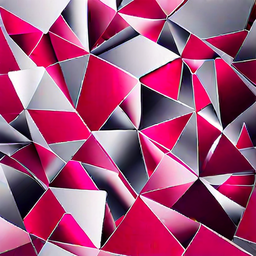

layer_difference=120
decoded text =  A
score=0.4381431579589844
svg length: 9399


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

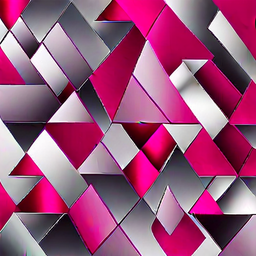

layer_difference=110
decoded text =  A
A
score=0.41596279144287107
svg length: 8788


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

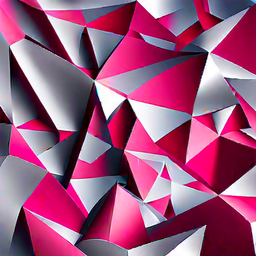

layer_difference=130
decoded text =  A
score=0.42057108879089355
svg length: 9246
final score: 0.4381431579589844


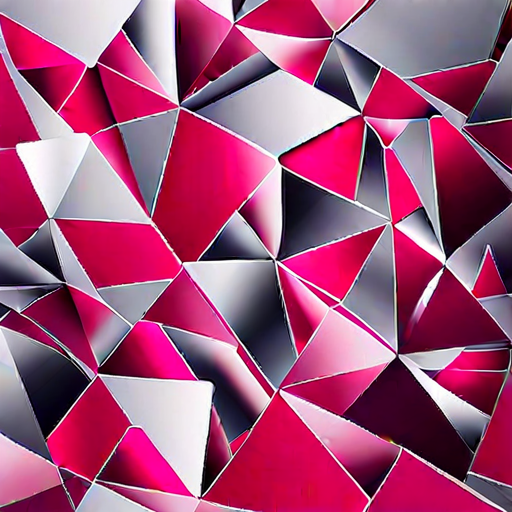

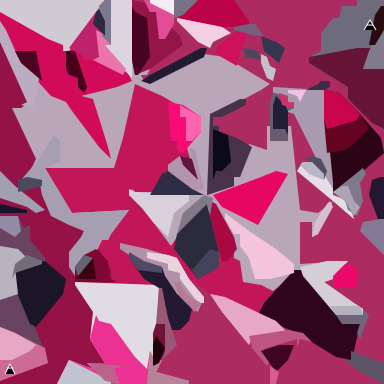

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#C11658"/><polygon points="44,0 128,0 128,128 63,128 51,125 52,122 51,122 51,111 53,95 49,94 43,86 44,84 48,87 54,89 61,99 66,102 66,98 64,93 71,99 82,112 83,112 95,110 86,105 88,101 98,90 101,90 112,104 121,105 117,101 108,95 107,93 112,91 115,88 100,88 100,74 104,74 105,78 110,68 106,72 99,70 97,50 96,47 90,47 89,50 84,49 80,59 78,59 78,62 69,65 70,38 89,28 73,19 66,20 50,28 47,27 47,25 45,25 44,20" fill="#AC2B60"/><polygon points="0,0 44,0 45,20 46,24 50,23 49,25 47,25 48,27 54,25 68,18 75,19 90,28 87,30 72,38 70,38 70,63 69,65 78,62 78,59 80,59 81,55 83,48 89,50 89,42 90,42 90,47 96,47 96,42 97,42 100,70 106,71 111,67 109,72 106,78 104,79 104,74 100,74 100,88 116,87 111,93 108,94 118,101 121,103 121,105 112,105 101,92 101,90 96,93 91,97 87,95 81,94 80,87 78,86 78,80 72,71 71,68 69,72 69,68 64,73 59,79 57,82 48,70 43,65 44,63 45,64 64,64 56,58 56,55 60,52 65,

In [15]:
%%time
r = train_df.iloc[9]
description = r.description
svg, img = model.predict_impl(description)
display(img)
display(SVG(svg))
print(svg)

In [16]:
metric.score_instance(r.multiple_choice_qa, svg, random_seed=42)

decoded text =  A


{'competition_score': 0.21278131546663112,
 'vqa_score': 0.18846521375286734,
 'ocr_score': 1.0,
 'aesthetic_score': 0.4397096633911133}

## Evaluate on train dataset (LB prediction!)

In [17]:
# import matplotlib.pyplot as plt
# %matplotlib inline

# import pandas as pd
# from tqdm.auto import tqdm
# tqdm.pandas()

# train_df.head()

# train_df['raw_res'] = train_df.description.progress_apply(model.predict_impl)
# train_df['svg'] = train_df.raw_res.apply(lambda x: x[0])
# train_df['bitmap'] = train_df.raw_res.apply(lambda x: x[1])

# train_df['bitmap_score'] = train_df.progress_apply(
#     lambda r: bitmap_score_instance(r.multiple_choice_qa, r.bitmap, random_seed=42),
#     axis=1,
# )
# train_df['svg_score'] = train_df.progress_apply(
#     lambda r: metric.score_instance(r.multiple_choice_qa, r.svg, random_seed=42),
#     axis=1,
# )

# for r in train_df.itertuples():
    
#     b_vqa = r.bitmap_score['vqa_score']
#     b_aesthetic = r.bitmap_score['aesthetic_score']
#     b_ocr = r.bitmap_score['ocr_score']
#     b_score = r.bitmap_score['competition_score']

#     s_vqa = r.svg_score['vqa_score']
#     s_aesthetic = r.svg_score['aesthetic_score']
#     s_ocr = r.svg_score['ocr_score']
#     s_score = r.svg_score['competition_score']
    
#     plt.figure(figsize=(12, 6))
#     plt.suptitle(r.description, y=0.93)
    
#     plt.subplot(1, 2, 1)
#     plt.imshow(np.array(r.bitmap))
#     plt.axis('off')
#     plt.title(f'bitmap: score={b_score:.2f}, vqa={b_vqa:.2f}, ocr={b_ocr:.2f}, aes={b_aesthetic:.2f}')

#     plt.subplot(1, 2, 2)
#     plt.imshow(metric.svg_to_png(r.svg))
#     plt.axis('off')
#     plt.title(f'svg: score={s_score:.2f}, vqa={s_vqa:.2f}, ocr={s_ocr:.2f}, aes={s_aesthetic:.2f}')

# mean_bitmap_score = pd.DataFrame(train_df['bitmap_score'].tolist()).mean(axis=0)
# print(mean_bitmap_score)

# mean_svg_score = pd.DataFrame(train_df['svg_score'].tolist()).mean(axis=0)
# print(mean_svg_score)

# print(f'Original bitmap score: {mean_bitmap_score.competition_score}')
# print(f'Final svg score: {mean_svg_score.competition_score}')